In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [90]:
df = pd.read_csv('/content/Iris.csv')
df.head()
df = df.drop("Id", axis=1)

In [91]:
print(f"Veri seti boyutu: {df.shape}")
print(f"Sınıf dağılımı:\n{df['Species'].value_counts()}")

Veri seti boyutu: (150, 5)
Sınıf dağılımı:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [92]:
X = df.drop('Species', axis=1)
y = df['Species']

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape}")
print(f"Test seti: {X_test.shape}")

Eğitim seti: (105, 4)
Test seti: (45, 4)


In [94]:
model = DecisionTreeClassifier(
    criterion='gini',      # Bölünme kriteri: Gini impurity
    max_depth=4,           # Maksimum derinlik (overfitting'i önlemek için)
    min_samples_split=10,  # Bir düğümü bölmek için minimum örnek sayısı
    min_samples_leaf=5,    # Bir yaprak düğümdeki minimum örnek sayısı
    random_state=42        # Tekrarlanabilirlik
)

model.fit(X_train, y_train)
print("Model eğitildi.")

Model eğitildi.


In [95]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Doğruluk (Accuracy): {accuracy:.4f}")
print()

print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Iris-setosa ', 'Iris-versicolor', 'Iris-virginica']))

Doğruluk (Accuracy): 0.8889

Sınıflandırma Raporu:
                 precision    recall  f1-score   support

   Iris-setosa        1.00      1.00      1.00        15
Iris-versicolor       0.86      0.80      0.83        15
 Iris-virginica       0.81      0.87      0.84        15

       accuracy                           0.89        45
      macro avg       0.89      0.89      0.89        45
   weighted avg       0.89      0.89      0.89        45



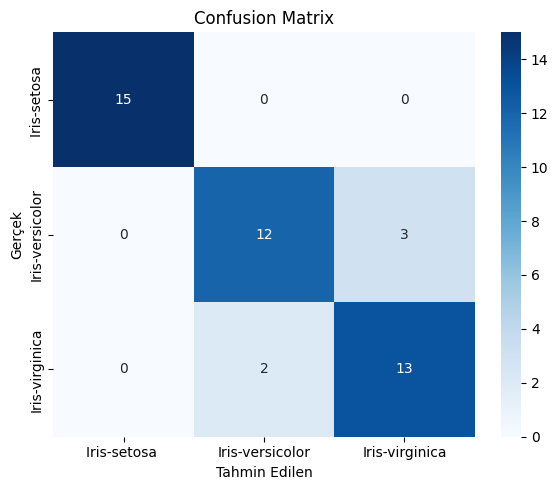

In [96]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Iris-setosa ', 'Iris-versicolor', 'Iris-virginica'],
            yticklabels=['Iris-setosa ', 'Iris-versicolor', 'Iris-virginica'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

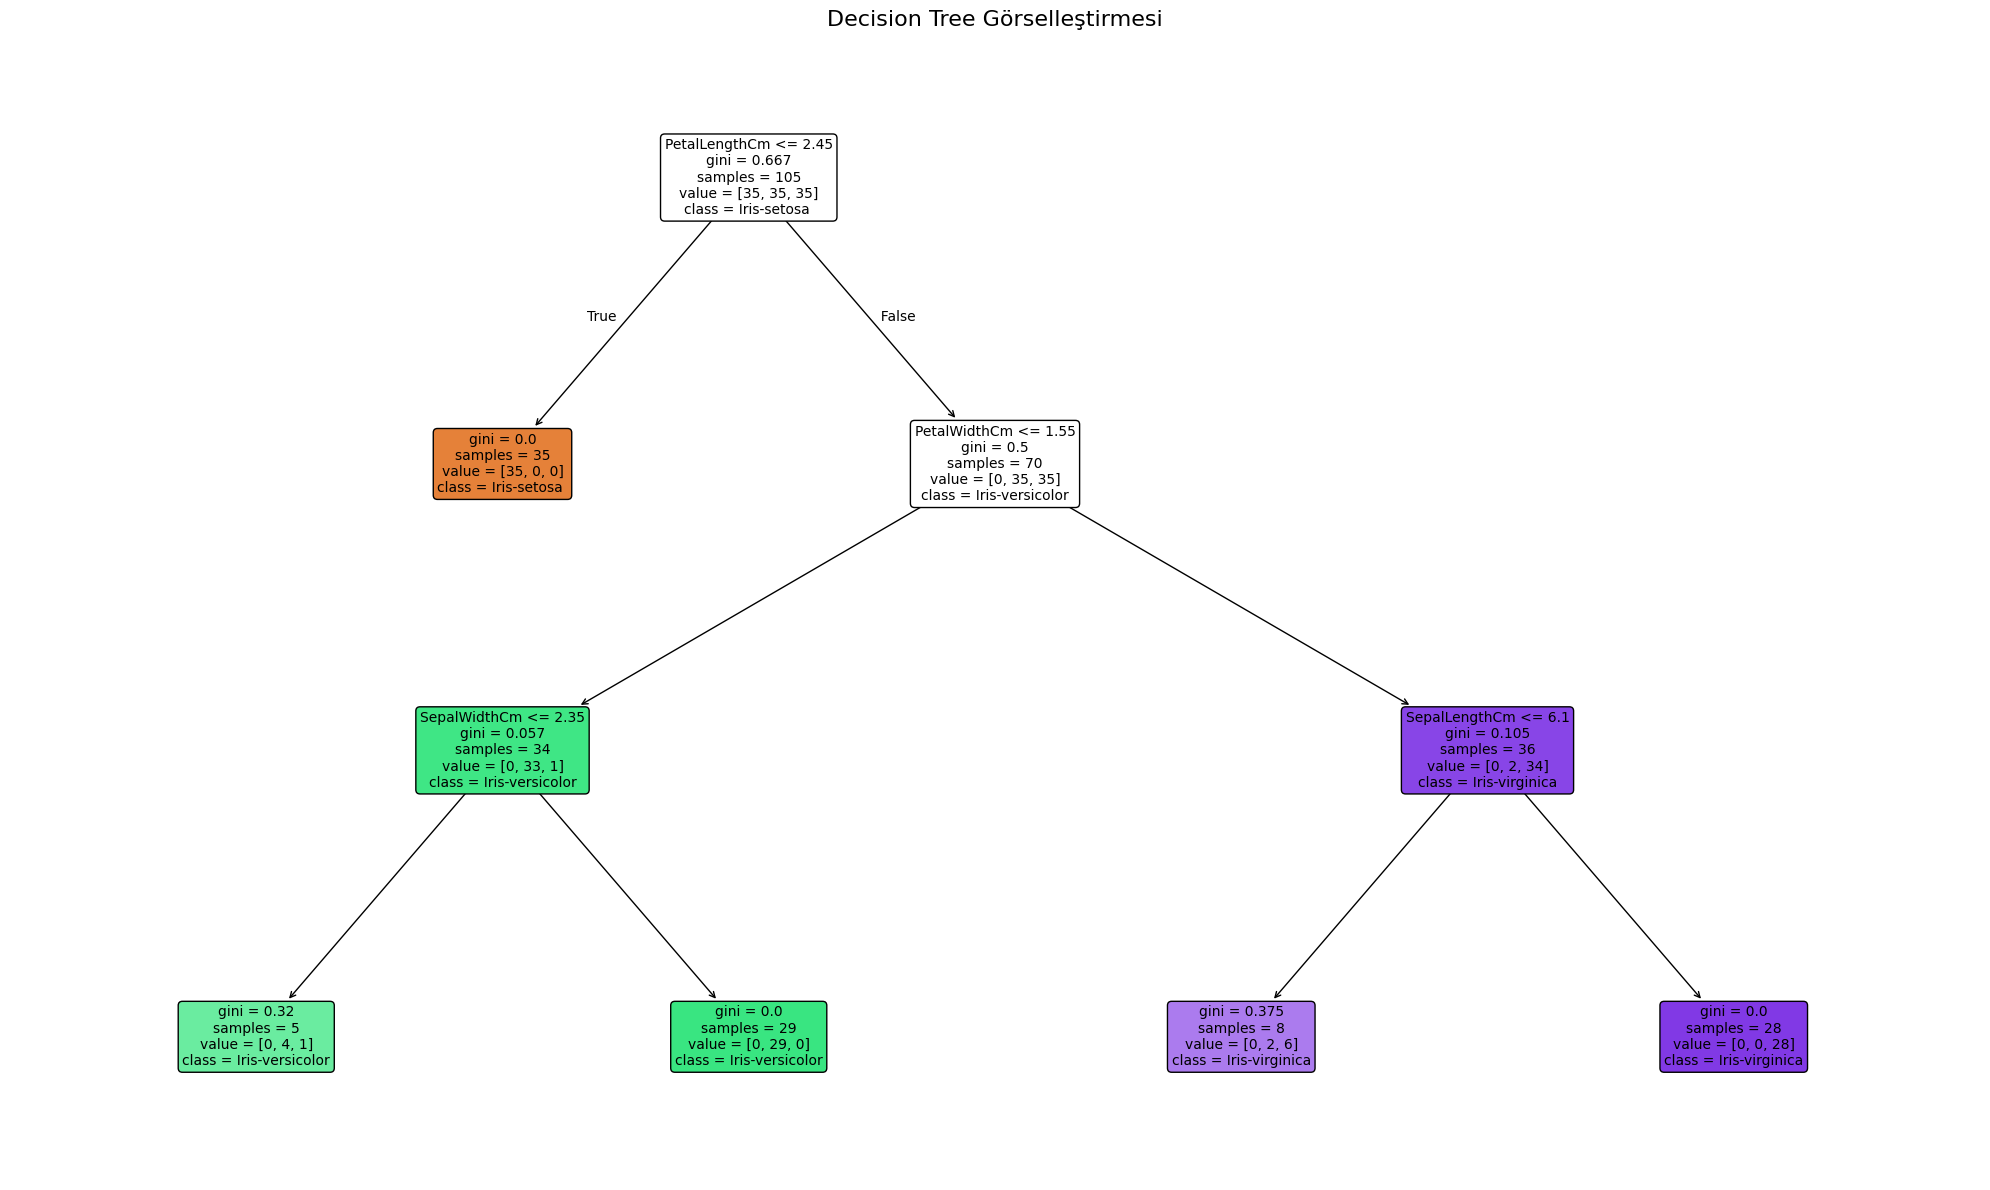

In [97]:
plt.figure(figsize=(20, 12))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Iris-setosa ', 'Iris-versicolor', 'Iris-virginica'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Görselleştirmesi', fontsize=16)
plt.tight_layout()
plt.show()

In [98]:
# Metinsel olarak karar ağacını görüntüle
tree_rules = export_text(
    model,
    feature_names=list(X.columns),
    spacing=3
)
print(tree_rules)

|--- PetalLengthCm <= 2.45
|   |--- class: Iris-setosa
|--- PetalLengthCm >  2.45
|   |--- PetalWidthCm <= 1.55
|   |   |--- SepalWidthCm <= 2.35
|   |   |   |--- class: Iris-versicolor
|   |   |--- SepalWidthCm >  2.35
|   |   |   |--- class: Iris-versicolor
|   |--- PetalWidthCm >  1.55
|   |   |--- SepalLengthCm <= 6.10
|   |   |   |--- class: Iris-virginica
|   |   |--- SepalLengthCm >  6.10
|   |   |   |--- class: Iris-virginica



En Önemli 10 Özellik:
         feature  importance
2  PetalLengthCm    0.535168
3   PetalWidthCm    0.447722
0  SepalLengthCm    0.011893
1   SepalWidthCm    0.005217


/tmp/ipykernel_6491/2263195374.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10),


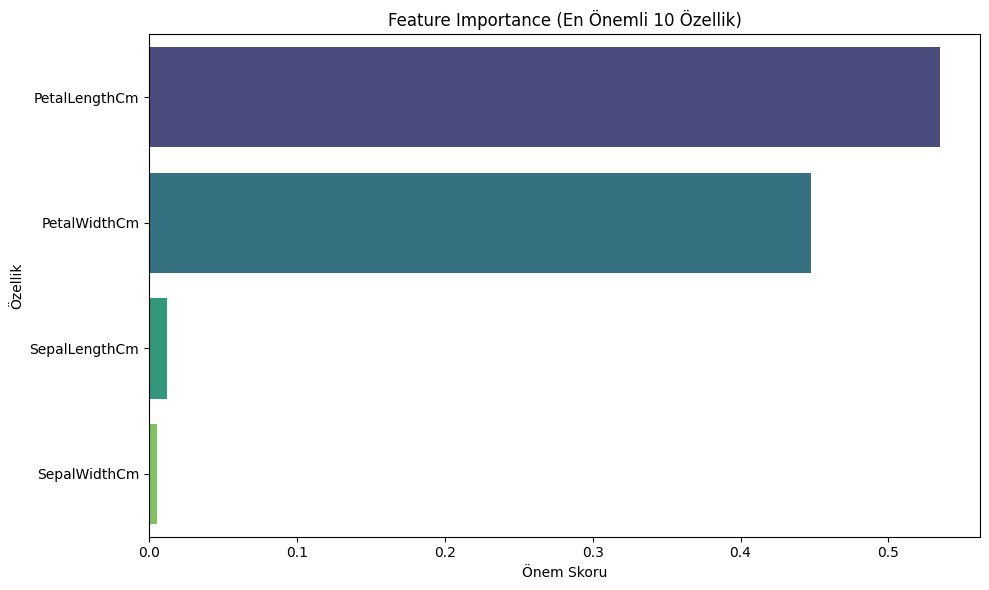

In [99]:
# Özellik önem sıralaması (Feature Importance)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("En Önemli 10 Özellik:")
print(feature_importance.head(10))

# Görselleştir
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10),
            x='importance', y='feature',
            palette='viridis')
plt.title('Feature Importance (En Önemli 10 Özellik)')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

In [100]:
# Modelin overfitting kontrolü için eğitim ve test doğruluklarını karşılaştır
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Eğitim Doğruluğu: {train_accuracy:.4f}")
print(f"Test Doğruluğu:   {test_accuracy:.4f}")

if train_accuracy - test_accuracy > 0.1:
    print("⚠️  Model overfitting yapıyor olabilir (eğitim-test farkı > %10).")
elif train_accuracy - test_accuracy > 0.05:
    print("⚠️  Hafif overfitting olabilir.")
else:
    print("✓  Model genellemesi iyi (overfitting yok).")

Eğitim Doğruluğu: 0.9714
Test Doğruluğu:   0.8889
⚠️  Hafif overfitting olabilir.
